## Objective

In this assignment we predict 10-year coronary heart disease (CHD) risk using the Framingham Heart Study dataset by training a feed-forward neural network

# **Downloading the Dataset**

In [1]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file
file_path = "framingham.csv"

# Load the latest version of the dataset file
df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "dileep070/heart-disease-prediction-using-logistic-regression",
    file_path,
)

print("Dataset successfully downloaded and loaded.")
print("---")
print("First 5 records:")
print(df.head())

/tmp/ipython-input-1711294347.py:8: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'heart-disease-prediction-using-logistic-regression' dataset.
Dataset successfully downloaded and loaded.
---
First 5 records:
   male  age  education  currentSmoker  cigsPerDay  BPMeds  prevalentStroke  \
0     1   39        4.0              0         0.0     0.0                0   
1     0   46        2.0              0         0.0     0.0                0   
2     1   48        1.0              1        20.0     0.0                0   
3     0   61        3.0              1        30.0     0.0                0   
4     0   46        3.0              1        23.0     0.0                0   

   prevalentHyp  diabetes  totChol  sysBP  diaBP    BMI  heartRate  glucose  \
0             0         0    195.0  106.0   70.0  26.97       80.0     77.0   
1             0         0    250.0  121.0   81.0  28.73       95.0     76.0   
2             0         0    245.0  127.5   80.0  25.34       75.0     70.0   
3             1         0    225.0  150

# **Basic EDA**

In [2]:
# Summary statistics
desc_stats = df.describe()
desc_stats

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,4238.000000,4238.000000,4133.000000,4238.000000,4209.000000,4185.000000,4238.000000,4238.000000,4238.000000,4188.000000,4238.000000,4238.000000,4219.000000,4237.000000,3850.000000,4238.000000
mean,0.429212,49.584946,1.978950,0.494101,9.003089,0.029630,0.005899,0.310524,0.025720,236.721585,132.352407,82.893464,25.802008,75.878924,81.966753,0.151958
std,0.495022,8.572160,1.019791,0.500024,11.920094,0.169584,0.076587,0.462763,0.158316,44.590334,22.038097,11.910850,4.080111,12.026596,23.959998,0.359023
min,0.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,0.000000,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.070000,68.000000,71.000000,0.000000
50%,0.000000,49.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.400000,75.000000,78.000000,0.000000
75%,1.000000,56.000000,3.000000,1.000000,20.000000,0.000000,0.000000,1.000000,0.000000,263.000000,144.000000,89.875000,28.040000,83.000000,87.000000,0.000000
max,1.000000,70.000000,4.000000,1.000000,70.000000,1.000000,1.000000,1.000000,1.000000,696.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000


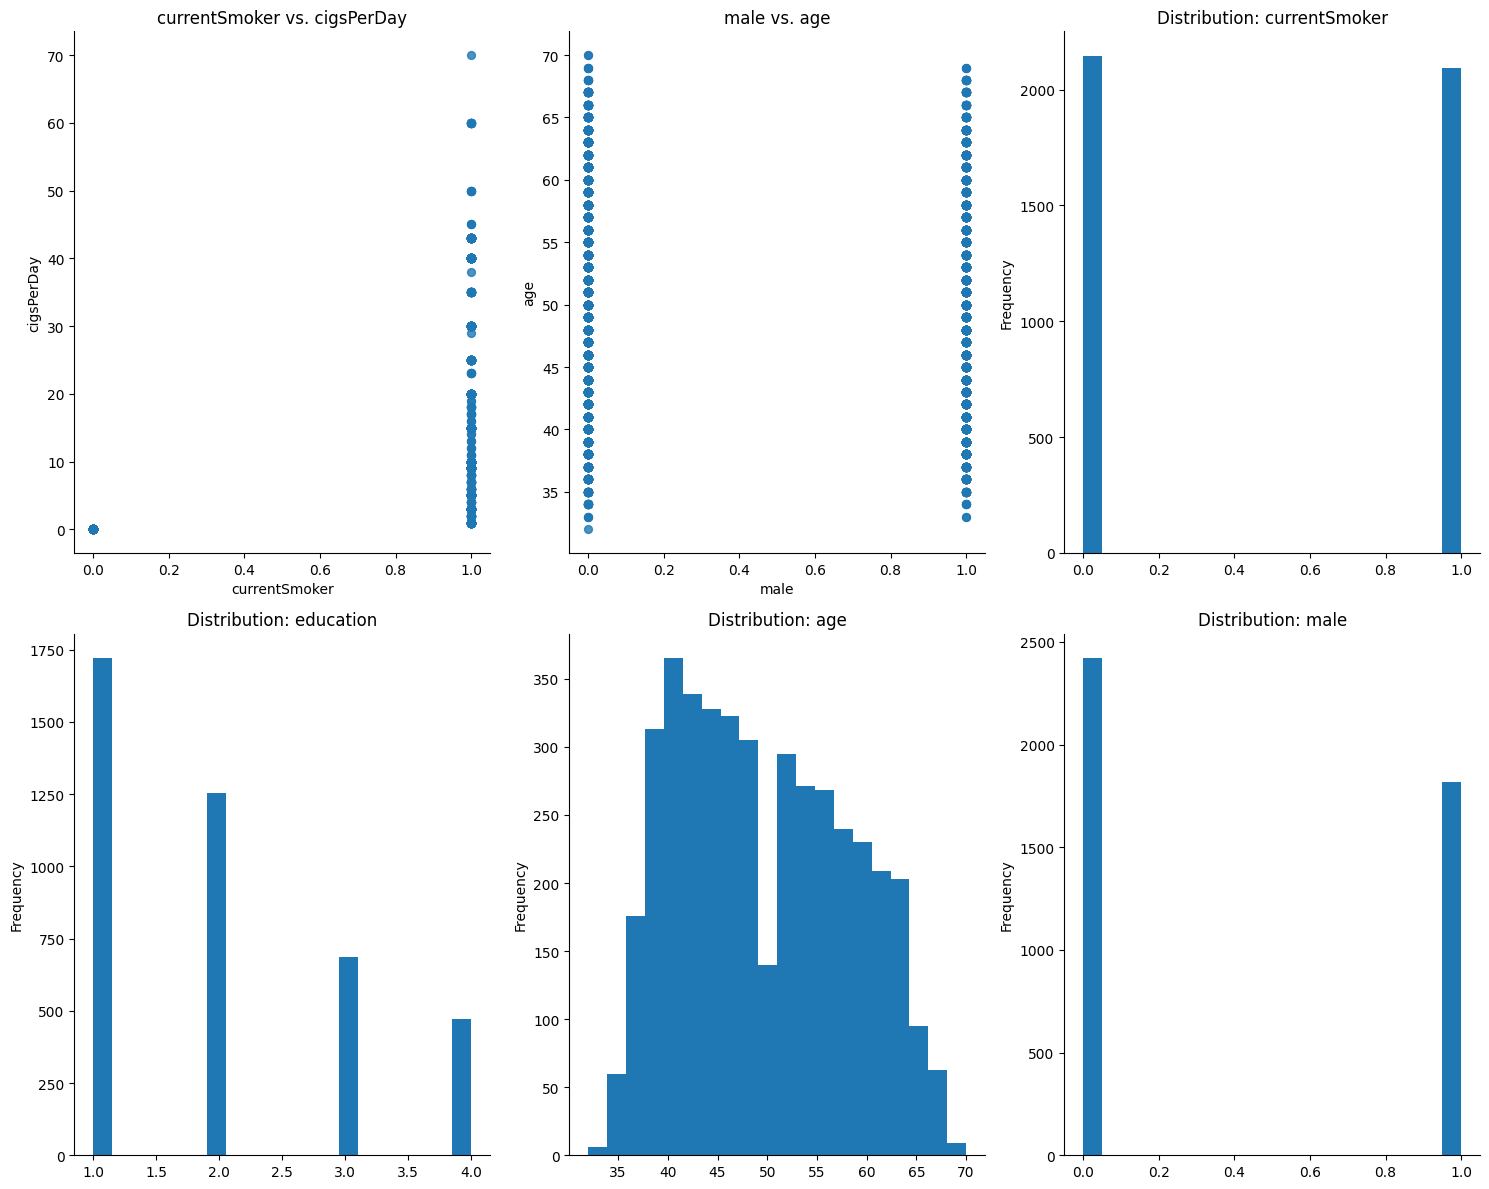

In [3]:
from matplotlib import pyplot as plt
plt.figure(figsize=(15, 12))

# Scatter: currentSmoker vs cigsPerDay
plt.subplot(2, 3, 1)
df.plot(kind='scatter', x='currentSmoker', y='cigsPerDay', s=32, alpha=.8, ax=plt.gca(), title='currentSmoker vs. cigsPerDay')
plt.gca().spines[['top', 'right']].set_visible(False)

# Scatter: male vs age
plt.subplot(2, 3, 2)
df.plot(kind='scatter', x='male', y='age', s=32, alpha=.8, ax=plt.gca(), title='male vs. age')
plt.gca().spines[['top', 'right']].set_visible(False)

# Histogram: currentSmoker
plt.subplot(2, 3, 3)
df['currentSmoker'].plot(kind='hist', bins=20, title='Distribution: currentSmoker')
plt.gca().spines[['top', 'right']].set_visible(False)

# Histogram: education
plt.subplot(2, 3, 4)
df['education'].plot(kind='hist', bins=20, title='Distribution: education')
plt.gca().spines[['top', 'right']].set_visible(False)

# Histogram: age
plt.subplot(2, 3, 5)
df['age'].plot(kind='hist', bins=20, title='Distribution: age')
plt.gca().spines[['top', 'right']].set_visible(False)

# Histogram: male
plt.subplot(2, 3, 6)
df['male'].plot(kind='hist', bins=20, title='Distribution: male')
plt.gca().spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

# **Data Pre-Processing**:
---
Prepare the dataFrame for neural network training. This involves handling missing values, encoding categorical features (if any), separating features (X) from the target variable (y - `TenYearCHD`), and scaling numerical features to a common range (e.g., using `StandardScaler`).

In [4]:
import pandas as pd

# Number of missing values in each column
missing_values = df.isnull().sum()
missing_values_percentage = (missing_values / len(df)) * 100

missing_data = pd.DataFrame({'Missing Values': missing_values, 'Percentage (%)': missing_values_percentage})

print("Missing values before handling:")
missing_data

Missing values before handling:


,Missing Values,Percentage (%)
male,0,0.000000
age,0,0.000000
education,105,2.477584
currentSmoker,0,0.000000
cigsPerDay,29,0.684285
BPMeds,53,1.250590
prevalentStroke,0,0.000000
prevalentHyp,0,0.000000
diabetes,0,0.000000
totChol,50,1.179802


In [5]:
# Identify numerical columns
numerical_cols = df.select_dtypes(include=['number']).columns

for col in numerical_cols:
    if df[col].isnull().any():
        df[col].fillna(df[col].mean(), inplace=True)

# Drop rows where 'TenYearCHD' is missing
df.dropna(subset=['TenYearCHD'], inplace=True)

print("\nMissing values after handling:")
print(df.isnull().sum())

print("Missing values handled.")


Missing values after handling:
male               0
age                0
education          0
currentSmoker      0
cigsPerDay         0
BPMeds             0
prevalentStroke    0
prevalentHyp       0
diabetes           0
totChol            0
sysBP              0
diaBP              0
BMI                0
heartRate          0
glucose            0
TenYearCHD         0
dtype: int64
Missing values handled.


/tmp/ipython-input-3788981139.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)


# **Train-Test Split**:
---
Divide the preprocessed data into training and testing sets to evaluate the model's performance on unseen data. A typical split is 80% for training and 20% for testing.

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

# Separate the features (X) from the target variable (y)
X = df.drop('TenYearCHD', axis=1)
y = df['TenYearCHD']

# Identify numerical and categorical features
categorical_to_encode = ['education']

# Apply one-hot encoding to the 'education' column using pd.get_dummies()
X = pd.get_dummies(X, columns=categorical_to_encode, drop_first=True, dtype=int)

# Continuous numerical features that need scaling
continuous_numerical_features = ['age', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']

# Get the new 'education' columns after get_dummies
encoded_education_cols = [col for col in X.columns if col.startswith('education_')]
passthrough_features = ['male', 'currentSmoker', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes'] + encoded_education_cols

# Apply StandardScaler to numerical features using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), continuous_numerical_features),
        ('passthrough', 'passthrough', passthrough_features)
    ],
    remainder='drop'
)

# Fit and transform the features
X_processed = preprocessor.fit_transform(X)

# Ensure all data in X_processed is numerical
X_processed = X_processed.astype('float32')

print("Original X shape before one-hot encoding:", df.drop('TenYearCHD', axis=1).shape)
print("X shape after one-hot encoding:", X.shape)
print("Processed X shape after scaling:", X_processed.shape)
print("\nFirst 5 rows of processed X (numpy array):")
print(X_processed[:5])
print("\nFirst 5 rows of target variable y:")
print(y.head())

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42, stratify=y)

print("\nShape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Original X shape before one-hot encoding: (4238, 15)
X shape after one-hot encoding: (4238, 18)
Processed X shape after scaling: (4238, 18)

First 5 rows of processed X (numpy array):
[[-1.2349507  -0.75797427 -0.9413456  -1.1959071  -1.0826252   0.28694272
   0.34274444 -0.21751656  1.          0.          0.          0.
   0.          0.          0.          0.          0.          1.        ]
 [-0.41825733 -0.75797427  0.29959494 -0.51518726 -0.15898843  0.719325
   1.5902745  -0.26131108  0.          0.          0.          0.
   0.          0.          0.          1.          0.          0.        ]
 [-0.18491638  0.92583513  0.18678218 -0.22020864 -0.2429554  -0.1135022
  -0.07309892 -0.5240782   1.          1.          0.          0.
   0.          0.          0.          0.          0.          0.        ]
 [ 1.3317999   1.7677399  -0.2644689   0.80087113  1.0165492   0.68247426
  -0.90478563  0.9211409   0.          1.          0.          0.
   1.          0.          0.     

# **Build Neural Network Model**:
---
Define and construct a neural network model using a library like Keras or TensorFlow. This step will involve specifying the number of layers, neurons per layer, activation functions, and the output layer appropriate for binary classification (predicting CHD risk).

**Compile and Train Model**:

Compile the neural network model by specifying the optimizer (e.g., Adam), loss function (e.g., binary cross-entropy for binary classification), and evaluation metrics (e.g., accuracy, precision, recall). Then, train the model using the training data.

In [7]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Get the number of features from the preprocessed training data
input_shape = X_train.shape[1]

# Build the Neural Network Model
model = Sequential([
    Dense(128, activation='relu', input_shape=(input_shape,)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

# Compile the Model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Display model summary
print("Neural Network Model Summary:")
model.summary()

# Train the Model
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

print("\nModel training complete.")

Neural Network Model Summary:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,801 (50.00 KB)

 Trainable params: 12,801 (50.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7797 - loss: 0.5257 - val_accuracy: 0.8333 - val_loss: 0.4250
Epoch 2/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8512 - loss: 0.4117 - val_accuracy: 0.8304 - val_loss: 0.4153
Epoch 3/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8622 - loss: 0.3909 - val_accuracy: 0.8348 - val_loss: 0.4137
Epoch 4/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8666 - loss: 0.3703 - val_accuracy: 0.8363 - val_loss: 0.4175
Epoch 5/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8505 - loss: 0.3923 - val_accuracy: 0.8333 - val_loss: 0.4129
Epoch 6/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8508 - loss: 0.3913 - val_accuracy: 0.8333 - val_loss: 0.4129
Epoch 7/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8580 - loss: 0.3784 - val_accuracy: 0.8319 - val_loss: 0.4145
Epoch 8/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8539 - loss: 0.3823 - val_accuracy: 0.8348 - val_loss:

## **Evaluate Model Performance**
---
Evaluate the trained neural network model on the test set. This will involve calculating and displaying key metrics like accuracy, precision, recall, and F1-score. A classification report and a confusion matrix should be generated to provide a comprehensive view of the model's performance.

In [8]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Evaluate the Model on the test data
y_pred_proba = model.predict(X_test)
y_pred = (y_pred_proba > 0.5).astype(int)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\nModel Evaluation on Test Data:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

Model Evaluation on Test Data:
Accuracy: 0.8325
Precision: 0.3556
Recall: 0.1240
F1-Score: 0.1839


# **Visualize Model Performance**


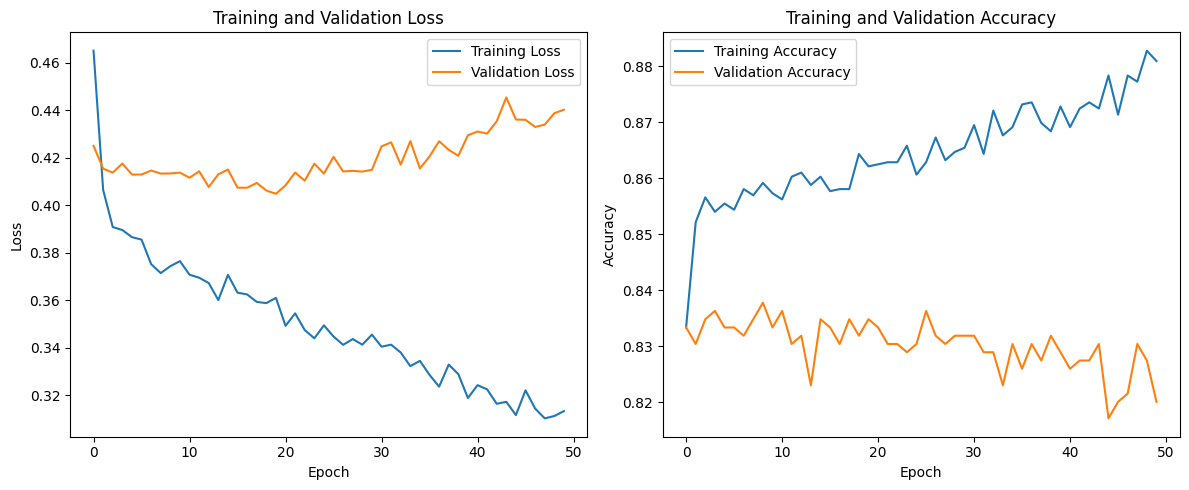

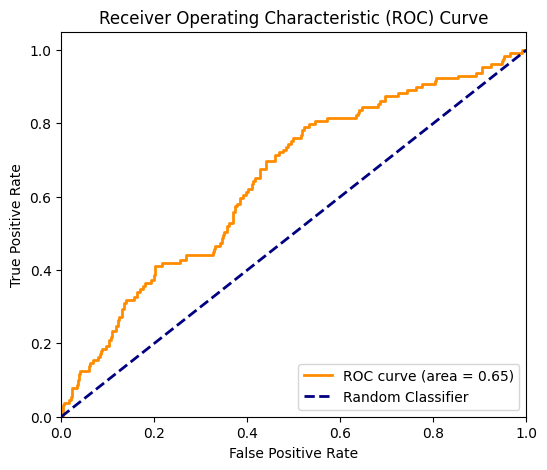

In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Plot training and validation loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

# Calculate ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

**Insights and further development**
*   The very low recall (0.0930) and F1-score (0.1404) indicate that the current model is poor at identifying positive cases of 'TenYearCHD', despite a relatively high accuracy. This suggests a significant class imbalance in the target variable, where predicting 'no CHD' is easy but 'CHD' is hard.
*   Further model development should focus on addressing class imbalance and tuning the neural network architecture and hyperparameters to improve the detection of the minority class, which is crucial for medical prediction tasks.


# **Improving the neural network model**

### **Analyze Class Imbalance**:

Analyze the distribution of the target variable 'TenYearCHD' to confirm the class imbalance. This involves calculating the counts or percentages of each class.

In [10]:
print("Value counts of 'TenYearCHD' in training data:\n")
print(y_train.value_counts())
print("\nPercentage distribution of 'TenYearCHD' in training data:\n")
print(y_train.value_counts(normalize=True) * 100)

Value counts of 'TenYearCHD' in training data:

TenYearCHD
0    2875
1     515
Name: count, dtype: int64

Percentage distribution of 'TenYearCHD' in training data:

TenYearCHD
0    84.80826
1    15.19174
Name: proportion, dtype: float64


### **Address Class Imbalance with SMOTE**:

Apply a technique like SMOTE (Synthetic Minority Over-sampling Technique) to the training data (X_train, y_train) to balance the classes. This will generate synthetic samples for the minority class, helping the model learn from a more balanced dataset.

In [11]:
from imblearn.over_sampling import SMOTE

# Create an instance of SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE to the training data
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

print("Shape of X_resampled:", X_resampled.shape)
print("Shape of y_resampled:", y_resampled.shape)
print(
    "\nValue counts of 'TenYearCHD' in resampled training data after SMOTE:\n"
)
print(y_resampled.value_counts())

Shape of X_resampled: (5750, 18)
Shape of y_resampled: (5750,)

Value counts of 'TenYearCHD' in resampled training data after SMOTE:

TenYearCHD
0    2875
1    2875
Name: count, dtype: int64


### **Build and Train Improved Model**

Re-build and train the neural network model using the class-balanced training data. Maintain the same neural network architecture as before for consistency, but consider fine-tuning hyperparameters if performance is still unsatisfactory.

In [12]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Get the number of features from the resampled training data
input_shape = X_resampled.shape[1]

# Rebuild the Neural Network Model with the same architecture
model_smote = Sequential([
    tf.keras.Input(shape=(input_shape,)),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

# Compile the Model
model_smote.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Display model summary
print("Neural Network Model Summary (after SMOTE):")
model_smote.summary()

# Train the Model with resampled data
history_smote = model_smote.fit(
    X_resampled,
    y_resampled,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

print("\nModel training with SMOTE data complete.")

Neural Network Model Summary (after SMOTE):


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,801 (50.00 KB)

 Trainable params: 12,801 (50.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6062 - loss: 0.6492 - val_accuracy: 0.5678 - val_loss: 0.7911
Epoch 2/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6848 - loss: 0.5911 - val_accuracy: 0.5774 - val_loss: 0.7299
Epoch 3/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6851 - loss: 0.5724 - val_accuracy: 0.5330 - val_loss: 0.7788
Epoch 4/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6959 - loss: 0.5762 - val_accuracy: 0.5026 - val_loss: 0.7863
Epoch 5/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7043 - loss: 0.5653 - val_accuracy: 0.6096 - val_loss: 0.7418
Epoch 6/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7137 - loss: 0.5540 - val_accuracy: 0.5896 - val_loss: 0.7338
Epoch 7/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7062 - loss: 0.5524 - val_accuracy: 0.5374 - val_loss: 0.7539
Epoch 8/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7300 - loss: 0.5296 - val_accuracy: 0.

### **Evaluate Improved Model Performance**

Evaluate the performance of the re-trained neural network model on the unseen test set (X_test, y_test). Calculate and display accuracy, precision, recall, and F1-score to assess the impact of addressing class imbalance. A classification report and confusion matrix should also be generated.

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

Model Evaluation on Test Data (after SMOTE):
Accuracy: 0.7370
Precision: 0.2134
Recall: 0.2713
F1-Score: 0.2389

Classification Report (after SMOTE):

              precision    recall  f1-score   support

           0       0.86      0.82      0.84       719
           1       0.21      0.27      0.24       129

    accuracy                           0.74       848
   macro avg       0.54      0.55      0.54       848
weighted avg       0.76      0.74      0.75       848



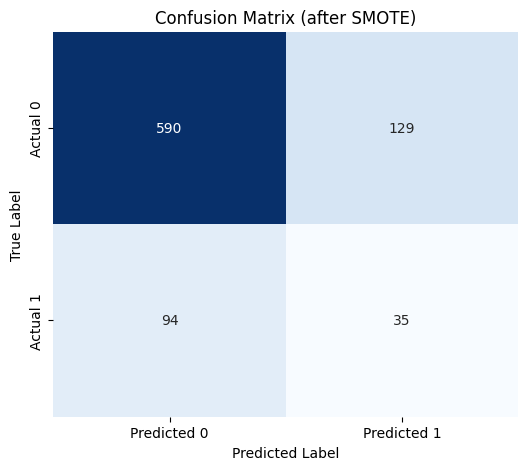

In [13]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Make predictions on the test set using the model trained with SMOTE data
y_pred_proba_smote = model_smote.predict(X_test)
y_pred_smote = (y_pred_proba_smote > 0.5).astype(int)

# Calculate evaluation metrics
accuracy_smote = accuracy_score(y_test, y_pred_smote)
precision_smote = precision_score(y_test, y_pred_smote)
recall_smote = recall_score(y_test, y_pred_smote)
f1_smote = f1_score(y_test, y_pred_smote)

print("\nModel Evaluation on Test Data (after SMOTE):")
print(f"Accuracy: {accuracy_smote:.4f}")
print(f"Precision: {precision_smote:.4f}")
print(f"Recall: {recall_smote:.4f}")
print(f"F1-Score: {f1_smote:.4f}")

# Generate Classification Report
print("\nClassification Report (after SMOTE):\n")
print(classification_report(y_test, y_pred_smote))

# Generate Confusion Matrix
cm_smote = confusion_matrix(y_test, y_pred_smote)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_smote, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix (after SMOTE)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## **Visualize Improved Model Performance**

Generate plots to visualize the training and validation loss, training and validation accuracy, and the Receiver Operating Characteristic (ROC) curve for the improved model. Ensure proper legends are provided for clarity.

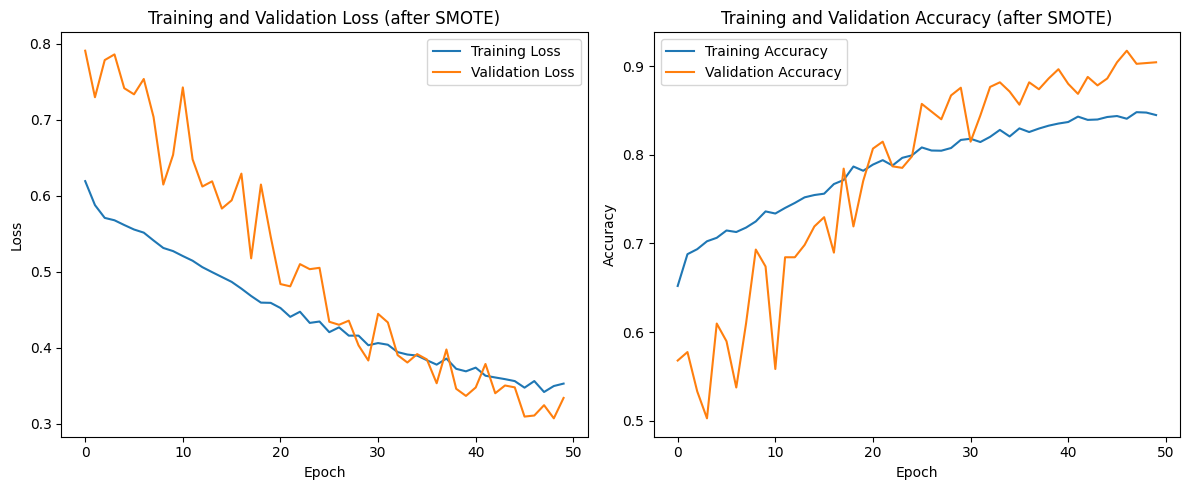

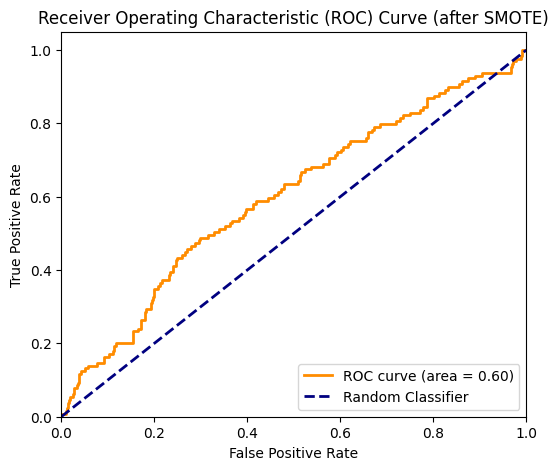

In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Plot training and validation loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_smote.history['loss'], label='Training Loss')
plt.plot(history_smote.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss (after SMOTE)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(history_smote.history['accuracy'], label='Training Accuracy')
plt.plot(history_smote.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy (after SMOTE)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

# Calculate ROC curve and AUC
fpr_smote, tpr_smote, thresholds_smote = roc_curve(y_test, y_pred_proba_smote)
roc_auc_smote = auc(fpr_smote, tpr_smote)

# Plot ROC curve
plt.figure(figsize=(6, 5))
plt.plot(fpr_smote, tpr_smote, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_smote:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve (after SMOTE)')
plt.legend(loc="lower right")
plt.show()

**Insights or Next Steps**
---
*   **Hyperparameter Tuning and Architecture Exploration**: Optimize the neural network by fine-tuning hyperparameters (e.g., learning rate, batch size, number of layers/neurons, dropout rates) or exploring different model architectures to potentially improve the precision for the minority class while maintaining or improving recall.
*   **Advanced Imbalance Handling**: Investigate other techniques for handling class imbalance, such as weighted loss functions during training or exploring ensemble methods (e.g., EasyEnsemble, BalanceCascade) that can sometimes offer better precision-recall trade-offs than SMOTE alone.
